In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
import torch
from sklearn.preprocessing import StandardScaler
import pandas as pd

A neural network with no hidden layers and no activation functions behaves exactly like a linear regression model.
It computes:

$$
\hat{y} = XW + b
$$

No non-linearity, no depth—just a direct, weighted transformation of inputs.

Key Insight:
Linear models are the core units of deep learning.
What makes neural networks powerful is that we stack these units and introduce non-linear functions between them.

# Mathematical Flow Of Linear Model

# The Input Matrix ($X$)

This is the dataset. It has a shape of $(1000, 8)$. Every row is a specific concrete mixture, and every column is one of the 8 features (Cement, Slag, Water, etc.).

$$X = \begin{bmatrix} x_{1,1} & x_{1,2} & x_{1,3} & \dots & x_{1,8} \\ x_{2,1} & x_{2,2} & x_{2,3} & \dots & x_{2,8} \\ x_{3,1} & x_{3,2} & x_{3,3} & \dots & x_{3,8} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ x_{1000,1} & x_{1000,2} & x_{1000,3} & \dots & x_{1000,8} \end{bmatrix}$$


# The Weights Vector ($W$ or $\omega$)

This is the list of multipliers the model learns. It has a shape of $(8, 1)$. There is exactly one weight for each of your 8 columns.

$$W = \begin{bmatrix} \omega_1 \\ \omega_2 \\ \omega_3 \\ \vdots \\ \omega_8 \end{bmatrix}$$

# The Bias ($b$ or $\beta$)

The bias is just a single scalar number (e.g., $b = 5.2$).During matrix addition, the computer automatically "broadcasts" it into a $(1000, 1)$ column so it can be added to every single row:

$$b = \begin{bmatrix} \beta \\ \beta \\ \beta \\ \vdots \\ \beta \end{bmatrix}$$

# The Output Vector ($\hat{y}$)

When the model calculates $XW + b$, it multiplies the grids together and outputs your final predictions. The result is a $(1000, 1)$ column vector, representing the predicted compressive strength for every single row in your dataset.

$$\hat{y} = \begin{bmatrix} (\omega_1 x_{1,1} + \omega_2 x_{1,2} + \dots + \omega_8 x_{1,8}) + \beta \\ (\omega_1 x_{2,1} + \omega_2 x_{2,2} + \dots + \omega_8 x_{2,8}) + \beta \\ (\omega_1 x_{3,1} + \omega_2 x_{3,2} + \dots + \omega_8 x_{3,8}) + \beta \\ \vdots \\ (\omega_1 x_{1000,1} + \omega_2 x_{1000,2} + \dots + \omega_8 x_{1000,8}) + \beta \end{bmatrix} = \begin{bmatrix} \hat{y}_1 \\ \hat{y}_2 \\ \hat{y}_3 \\ \vdots \\ \hat{y}_{1000} \end{bmatrix}$$

<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1432/953760225.py:38: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_ylabel("Predicted Value ($\hat{y}$)")


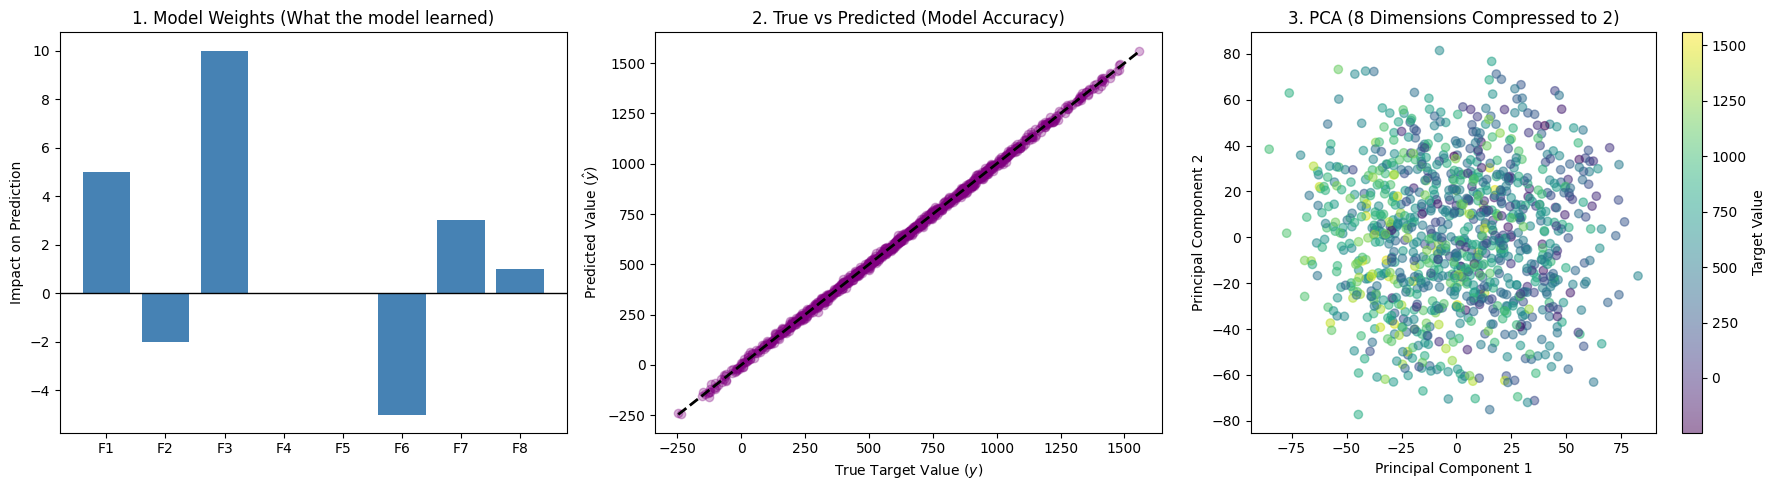

In [4]:


# ---------------------------------------------------------
# 1. THE DATA & MODEL: (1,000 rows, 8 columns)
# ---------------------------------------------------------
np.random.seed(42)

# Generate X matrix: 1000 rows, 8 columns
X = np.random.rand(1000, 8) * 100

# Generate a synthetic target y using fake true weights and add some noise
true_weights = np.array([5, -2, 10, 0, 0, -5, 3, 1])
y = X @ true_weights + 50 + (np.random.randn(1000) * 10)

# Train the model to find W and b
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
W = model.coef_

# ---------------------------------------------------------
# 2. THE VISUALIZATIONS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Visualizing the Logic (The Weights) ---
# Instead of plotting the data, we plot the 8 learned weights.
features = [f"F{i+1}" for i in range(8)]
axes[0].bar(features, W, color='steelblue')
axes[0].set_title("1. Model Weights (What the model learned)")
axes[0].set_ylabel("Impact on Prediction")
axes[0].axhline(0, color='black', lw=1)

# --- Plot 2: Visualizing the Mistakes (Residuals) ---
# We ignore the 8 features and just compare True y vs. Predicted y.
axes[1].scatter(y, y_pred, alpha=0.3, color='purple')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Ideal line
axes[1].set_title("2. True vs Predicted (Model Accuracy)")
axes[1].set_xlabel("True Target Value ($y$)")
axes[1].set_ylabel("Predicted Value ($\hat{y}$)")

# --- Plot 3: Dimensionality Reduction (PCA) ---
# We mathematically crush the (1000, 8) matrix into a (1000, 2) matrix.
pca = PCA(n_components=2)
X_compressed = pca.fit_transform(X)

# We can now plot the entire dataset on a flat 2D screen.
# The color represents the target variable (y).
scatter = axes[2].scatter(X_compressed[:, 0], X_compressed[:, 1], c=y, cmap='viridis', alpha=0.5)
axes[2].set_title("3. PCA (8 Dimensions Compressed to 2)")
axes[2].set_xlabel("Principal Component 1")
axes[2].set_ylabel("Principal Component 2")
plt.colorbar(scatter, ax=axes[2], label='Target Value')

plt.tight_layout()
plt.show()

In [5]:
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
Y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])

# 1. Manually initialize weight and bias tensors with requires_grad=True
W = torch.tensor([[0.5]], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

# 2. Define the predict function using matrix multiplication (@)
def predict(X):
    return X @ W + b

# 3. Compute the predicted output
y_pred = predict(X)

# 4. Print the result
print(y_pred)

tensor([[0.5000],
        [1.0000],
        [1.5000],
        [2.0000]], grad_fn=<AddBackward0>)


# Loss Function

#### **Mean Squared Error (MSE)**

For regression tasks, the most common loss function is the **Mean Squared Error (MSE)**.

It is defined as:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Where:
- $y_i$ = the actual value  
- $\hat{y}_i$ = the predicted value  
- $n$ = number of examples

#### **How It Works:**

1. Take the **difference** between prediction and actual value  
2. **Square** the difference (to penalize large errors more strongly)  
3. **Average** across all data points

This gives us a single loss value representing overall prediction error.

In [6]:
# 1. Define the MSE loss function
def mse_loss(predictions, targets):
    return torch.mean((targets - predictions) ** 2)

# 2. Use the provided tensors
Y_true = torch.tensor([3.0, 5.0, 7.0, 9.0, 11.0])
Y_pred = torch.tensor([2.5, 5.5, 6.0, 9.0, 12.0])

# 3. Compute the MSE
loss = mse_loss(Y_pred, Y_true)

# 4. Print the result
print(loss.item())

0.5


## Preparing the Data and Model

This is a critical setup step. A model with poor data preparation or unstable initialization will struggle to learn, even if the math is correct.

We’ll:
1. Load the Concrete dataset
2. Normalize the input features for stability
3. Split the data into training and test sets
4. Initialize the model parameters: weights `W` and bias `b`

#### **Data & Model Setup: High-Level Plan**

```text
Load CSV
    ↓
Extract inputs & targets
    ↓
Standardize features (mean=0, std=1)
    ↓
Split into 80% train, 20% test
    ↓
Initialize W and b with gradient tracking
```



In [9]:
df = pd.read_csv("/content/drive/MyDrive/concrete_data_clean.csv")
df.head()

,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [10]:
inputs = df.drop('compressive_strength', axis=1).values
targets = df['compressive_strength'].values.reshape(-1, 1)

In [11]:
scaler = StandardScaler()

inputs_scaled = scaler.fit_transform(inputs)


In [12]:
inputs_tensor = torch.tensor(inputs_scaled, dtype=torch.float32)
targets_tensor = torch.tensor(targets, dtype=torch.float32)

In [13]:
n_samples = inputs_tensor.shape[0]
indices = torch.randperm(n_samples)
split_idx = int(n_samples * 0.8)

In [14]:
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train = inputs_tensor[train_indices]
y_train = targets_tensor[train_indices]
X_test = inputs_tensor[test_indices]
y_test = targets_tensor[test_indices]

In [15]:
num_features = X_train.shape[1]
W = torch.randn((num_features, 1), requires_grad=True)
W.data *= 0.01
b = torch.zeros((1,), requires_grad=True)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Weight shape:", W.shape)
print("Bias shape:", b.shape)

Training set size: 824
Test set size: 206
Weight shape: torch.Size([8, 1])
Bias shape: torch.Size([1])


# The Engine of Learning: requires_grad=True

This is the most critical concept and the defining feature of PyTorch.
If you just do matrix math using standard Python or NumPy, the computer calculates the answer and immediately forgets how it got there. By adding requires_grad=True to  tensors, you turn on PyTorch's Automatic Differentiation engine (Autograd).

## How it works:

1. The Tape Recorder: PyTorch starts recording every single mathematical operation that involves $W$ and $b$, building a hidden "computation graph.

2. "The Mistake (Loss): The model makes its predictions ($\hat{y}$) and compares them to the actual true answers. The difference between them is the Loss ($L$).

3. The Chain Rule (.backward()): When the model makes a mistake, PyTorch hits rewind on the tape recorder. It uses calculus (the chain rule) to trace the errors backward through the computation graph.

4. The Gradient ($\nabla_\phi L$): The symbol $\nabla$ means gradient, $\phi$ represents your parameters ($W$ and $b$), and $L$ is the Loss. PyTorch calculates exactly how much the Loss would change if you slightly tweaked $W$ and $b$.

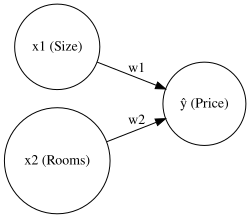

In [16]:
from graphviz import Digraph


dot = Digraph(engine='dot')
dot.attr(rankdir='LR')


dot.node('x1', 'x1 (Size)', shape='circle')
dot.node('x2', 'x2 (Rooms)', shape='circle')
dot.node('yhat', 'ŷ (Price)', shape='circle')


dot.edge('x1', 'yhat', label='w1')
dot.edge('x2', 'yhat', label='w2')


dot

# The Gradients

After calculating the MSE Loss, PyTorch uses calculus to find the gradients (slopes).

$\frac{dL}{d\beta}$ or $\Delta_{\beta} L$.

These numbers represent exactly how the Loss ($L$) responds if you tweak a parameter:

$\frac{dL}{d\beta} = +5$: The positive sign (and up arrow) means if you increase the bias $\beta$, the error goes up.

$\frac{dL}{dw_1} = +9$: If you increase $w_1$, the error goes up sharply.

$\frac{dL}{dw_2} = -7$: The negative sign (and down arrow) means if you increase $w_2$, the error actually goes down.

# How it works:

The core gradient descent formula is:

$$\phi_{new} = \phi_{current} - \eta \cdot \nabla L$$

Let's assume our model is just starting out, so all of our parameters are randomly set to $10.0$, and we choose a standard learning rate ($\eta$) of $0.1$.

# Updating $w_1$ (The Steep Error)

The gradient for $w_1$ was $+9$. This positive number means our current weight is causing the error to shoot up. The math forces the weight to decrease.$$w_1^{(new)} = 10.0 - (0.1 \cdot 9)$$$$w_1^{(new)} = 10.0 - 0.9$$$$w_1^{(new)} = \mathbf{9.1}$$

# Updating $w_2$ (The Negative Slope)

The gradient for $w_2$ was $-7$. Because the slope is pointing downward, the error will decrease if we keep moving forward.

The double-negative in the math forces the weight to increase.$$w_2^{(new)} = 10.0 - (0.1 \cdot -7)$$$$w_2^{(new)} = 10.0 - (-0.7)$$$$w_2^{(new)} = 10.0 + 0.7$$$$w_2^{(new)} = \mathbf{10.7}$$

# Updating $\beta$ (The Bias)

The gradient for the bias was $+5$. Similar to $w_1$, the positive slope means we need to pull this parameter back to reduce the loss.

$$\beta^{(new)} = 10.0 - (0.1 \cdot 5)$$$$\beta^{(new)} = 10.0 - 0.5$$$$\beta^{(new)} = \mathbf{9.5}$$

# Training Loop


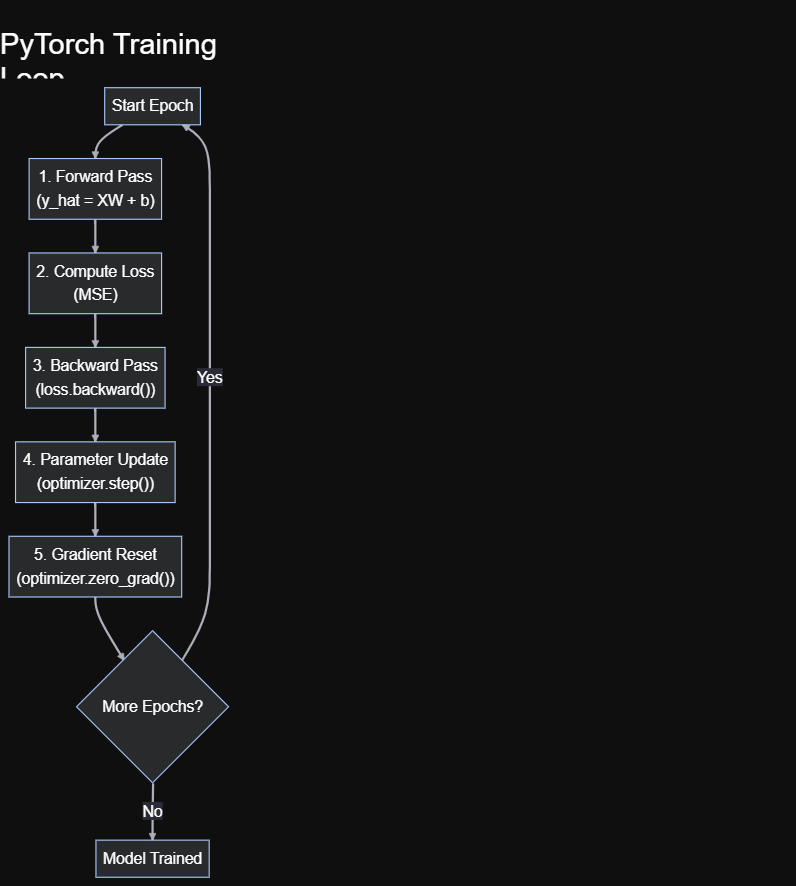

In [17]:
learning_rate = 0.001
epochs = 100

# Training loop
for epoch in range(epochs):
    # 1. Forward pass: compute predictions
    y_pred = predict(X_train)

    # 2. Compute loss
    loss = mse_loss(y_pred, y_train)

    # 3. Backward pass: compute gradients
    loss.backward()

    # 4. Update parameters
    with torch.no_grad():
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad

    # 5. Zero gradients
    W.grad.zero_()
    b.grad.zero_()

    # Print loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

Epoch 10: Loss = 1522.7692
Epoch 20: Loss = 1466.7063
Epoch 30: Loss = 1412.9199
Epoch 40: Loss = 1361.3146
Epoch 50: Loss = 1311.8004
Epoch 60: Loss = 1264.2903
Epoch 70: Loss = 1218.7014
Epoch 80: Loss = 1174.9539
Epoch 90: Loss = 1132.9722
Epoch 100: Loss = 1092.6832


# Plot Training Loss

Epoch 10: Loss = 1054.0175
Epoch 20: Loss = 1016.9081
Epoch 30: Loss = 981.2913
Epoch 40: Loss = 947.1058
Epoch 50: Loss = 914.2930
Epoch 60: Loss = 882.7969
Epoch 70: Loss = 852.5635
Epoch 80: Loss = 823.5415
Epoch 90: Loss = 795.6812
Epoch 100: Loss = 768.9354
Epoch 110: Loss = 743.2590
Epoch 120: Loss = 718.6082
Epoch 130: Loss = 694.9415
Epoch 140: Loss = 672.2191
Epoch 150: Loss = 650.4028
Epoch 160: Loss = 629.4555
Epoch 170: Loss = 609.3424
Epoch 180: Loss = 590.0297
Epoch 190: Loss = 571.4851
Epoch 200: Loss = 553.6775
Epoch 210: Loss = 536.5772
Epoch 220: Loss = 520.1558
Epoch 230: Loss = 504.3860
Epoch 240: Loss = 489.2415
Epoch 250: Loss = 474.6969
Epoch 260: Loss = 460.7286
Epoch 270: Loss = 447.3131
Epoch 280: Loss = 434.4284
Epoch 290: Loss = 422.0531
Epoch 300: Loss = 410.1668
Epoch 310: Loss = 398.7500
Epoch 320: Loss = 387.7838
Epoch 330: Loss = 377.2502
Epoch 340: Loss = 367.1320
Epoch 350: Loss = 357.4127
Epoch 360: Loss = 348.0760
Epoch 370: Loss = 339.1069
Epoch 38

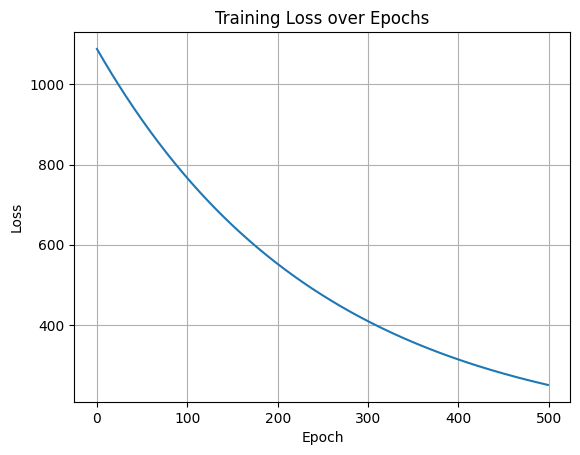

In [18]:


losses = []


learning_rate = 0.001
epochs = 500

for epoch in range(epochs):
    y_pred = predict(X_train)
    loss = mse_loss(y_pred, y_train)
    losses.append(loss.item())

    loss.backward()

    with torch.no_grad():
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad

    W.grad.zero_()
    b.grad.zero_()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

# Plot loss curve
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()



# Evaluation Steps

1. Use the final model (W, b) to predict on `X_test`
2. Compute MSE between predicted and true test values
3. Compare test loss to training loss

#### **Interpreting the Results**

| Observation                      | Diagnosis            |
|----------------------------------|----------------------|
| Both train and test loss high   | ❌ Underfitting       |
| Train loss low, test loss high  | ❌ Overfitting        |
| Both reasonably low             | ✅ Generalization     |

> ✅ We aim for **low loss on both sets**. That’s a sign of a model that has *learned general patterns* in the data.

In [20]:
# 1. Generate predictions on the training data
y_train_pred = predict(X_train)

# 2. Compute the MAE loss using the training targets
train_mae_loss = mae_loss(y_train_pred, y_train)

# 3. Print the result
print(f"Train MAE Loss: {train_mae_loss.item():.4f}")

Train MAE Loss: 12.6498


In [19]:
def mae_loss(predictions, targets):
    return torch.mean(torch.abs(predictions - targets))

# 2 & 3. Compute the test loss using the existing X_test, y_test, and predict function
y_test_pred = predict(X_test)
test_mae_loss = mae_loss(y_test_pred, y_test)

# 4. Print the result
print(f"Test MAE Loss: {test_mae_loss.item():.4f}")

Test MAE Loss: 11.9470


# Insights

# The Model Is Underfitting

The Model assumes a linear relationship between features

# (The Model Lacks Non-linearity)